# [비즈니스 최적화] 임계값 튜닝 및 비용 절감 분석

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, ClassLabel
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

🚀 Device: cuda


Casting the dataset: 100%|██████████| 1053/1053 [00:00<00:00, 233213.76 examples/s]


✅ 데이터 복구 완료: Test Set Size = 158


Map: 100%|██████████| 158/158 [00:00<00:00, 3896.81 examples/s]
/tmp/ipykernel_88/2962136497.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)



🔍 예측 수행 중...



Threshold  | Hard Recall (품질방어)     | Hard Precision (비용절감)  | F1 Score  


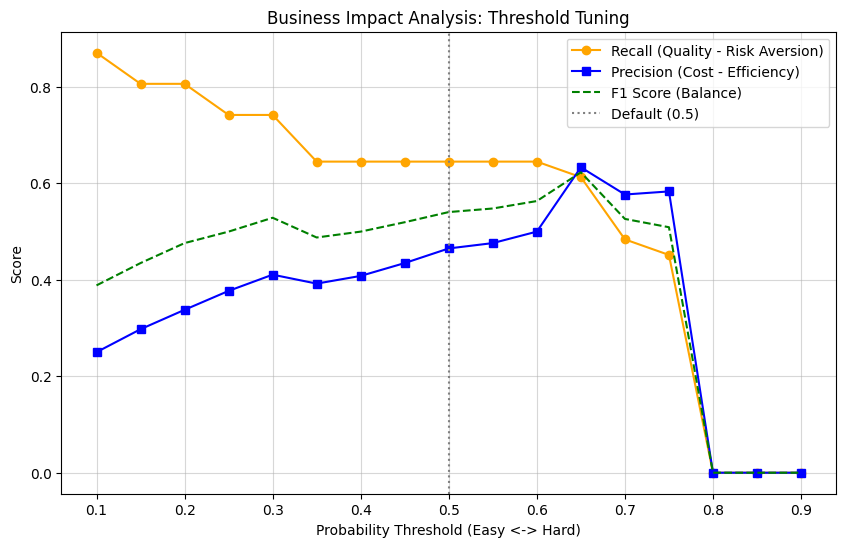


💡 [추천 전략] 품질 우선(Recall 80%+) 시 최적 임계값: 0.20


In [12]:
# ---------------------------------------------------------
# 1. 데이터 재로드 및 전처리 (메모리 복구)
# ---------------------------------------------------------
# 파일 경로 확인 (업로드해주신 파일명 기준)
DATA_PATH = "./data/munch_labeled_FINAL_190139.csv"
df = pd.read_csv(DATA_PATH)

# 필요한 컬럼 확인 및 결측치 제거
df = df[['input_sentence', 'intensity', 'field', 'score']].dropna()

# [Target Label] Score 4점 이상 = 1 (Hard), 미만 = 0 (Easy)
df['label'] = df['score'].apply(lambda x: 1 if x >= 4 else 0).astype(int)

# [Feature Engineering] 텍스트 증강 (학습 때와 동일하게)
def combine_features(row):
    intensity_tag = f"[{str(row['intensity']).upper()}]"
    field_tag = f"[{str(row['field']).upper()}]"
    return f"{intensity_tag} {field_tag} {row['input_sentence']}"

df['text'] = df.apply(combine_features, axis=1)

# Dataset 객체 생성
dataset = Dataset.from_pandas(df[['text', 'label']])

# [중요] Stratify 에러 방지용 ClassLabel 변환
dataset = dataset.cast_column("label", ClassLabel(num_classes=2, names=["Easy", "Hard"]))

# [중요] 학습 시점과 동일한 Seed(42)로 분할해야 "본 적 없는" Test Set이 유지됨
SEED = 42
train_test_split = dataset.train_test_split(test_size=0.15, seed=SEED, stratify_by_column="label")
test_dataset = train_test_split['test']

print(f"✅ 데이터 복구 완료: Test Set Size = {len(test_dataset)}")

# ---------------------------------------------------------
# 2. 토크나이징 및 모델 로드
# ---------------------------------------------------------
MODEL_PATH = "./output/smart_router_classifier" # 학습된 모델 경로
tokenizer = AutoTokenizer.from_pretrained("klue/roberta-base")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=128)

# Test 데이터셋 토크나이징
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# ---------------------------------------------------------
# 3. 예측 및 임계값(Threshold) 분석
# ---------------------------------------------------------
trainer = Trainer(model=model, tokenizer=tokenizer)
print("\n🔍 예측 수행 중...")
raw_pred = trainer.predict(tokenized_test)

# Logits -> Softmax -> Probability 추출
logits = torch.tensor(raw_pred.predictions)
probs = torch.nn.functional.softmax(logits, dim=-1)[:, 1].numpy() # Index 1 = Hard 확률
true_labels = raw_pred.label_ids

# 결과 저장용 리스트
results = []
thresholds = np.arange(0.1, 0.95, 0.05)

print("\n" + "="*80)
print(f"{'Threshold':<10} | {'Hard Recall (품질방어)':<22} | {'Hard Precision (비용절감)':<22} | {'F1 Score':<10}")
print("="*80)

for th in thresholds:
    pred_labels = (probs >= th).astype(int)

    recall = recall_score(true_labels, pred_labels, pos_label=1, zero_division=0)
    precision = precision_score(true_labels, pred_labels, pos_label=1, zero_division=0)
    f1 = f1_score(true_labels, pred_labels, pos_label=1, zero_division=0)

    results.append({"Threshold": th, "Recall": recall, "Precision": precision, "F1": f1})

    # 주요 구간 출력
    if th in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
         print(f"{th:.2f}       | {recall:.4f}                 | {precision:.4f}                 | {f1:.4f}")

# ---------------------------------------------------------
# 4. 시각화
# ---------------------------------------------------------
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(df_results["Threshold"], df_results["Recall"], label="Recall (Quality - Risk Aversion)", marker='o', color='orange')
plt.plot(df_results["Threshold"], df_results["Precision"], label="Precision (Cost - Efficiency)", marker='s', color='blue')
plt.plot(df_results["Threshold"], df_results["F1"], label="F1 Score (Balance)", linestyle='--', color='green')

plt.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
plt.title("Business Impact Analysis: Threshold Tuning")
plt.xlabel("Probability Threshold (Easy <-> Hard)")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# ---------------------------------------------------------
# [자동 추천]
# ---------------------------------------------------------
# Recall 80% 이상을 만족하면서 Precision이 가장 높은 지점 찾기
candidates = df_results[df_results["Recall"] >= 0.80]
if not candidates.empty:
    best_th = candidates.sort_values(by="Precision", ascending=False).iloc[0]["Threshold"]
    print(f"\n💡 [추천 전략] 품질 우선(Recall 80%+) 시 최적 임계값: {best_th:.2f}")
else:
    print("\n💡 [알림] Recall 80%를 넘는 구간이 없습니다. 데이터 추가 확보가 필요합니다.")